# F1 — Week 12 Performance Review

**Objective**: Review the optimisation performance of F1 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F1 (2D input, 1D output, maximisation)

This notebook loads the Week 12 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 1
N_DIMS = 2
N_INITIAL = 10
WEEK = 12
USE_LOG_SCALE = True  # F1 only
DATA_DIR = '../../data/f1/'

## Step 1 — Load Data

In [2]:
# Load Week 12 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F1 — Week 12 Data Summary
  Input dimensions:  2
  Total samples:     22
  Initial samples:   10
  Submissions:       12
  Input shape:       (22, 2)
  Output shape:      (22,)
  Best output:       7.71088e-16
  Worst output:      -0.00360606

Sample | x1 | x2 | y
-------------------------------------------------
   1(init) | 0.319404 | 0.762959 | 1.32268e-79
   2(init) | 0.574329 | 0.879898 | 1.03308e-46
   3(init) | 0.731024 | 0.733000 | 7.71088e-16
   4(init) | 0.840353 | 0.264732 | 3.34177e-124
   5(init) | 0.650114 | 0.681526 | -0.00360606
   6(init) | 0.410437 | 0.147554 | -2.15925e-54
   7(init) | 0.312691 | 0.078723 | -2.08909e-91
   8(init) | 0.683418 | 0.861057 | 2.535e-40
   9(init) | 0.082507 | 0.403488 | 3.60677e-81
  10(init) | 0.883890 | 0.582254 | 6.22986e-48
  11( wk3) | 0.448979 | 0.142857 | 2.31408e-56
  12( wk4) | 0.708964 | 0.494269 | -1.15988e-17
  13( wk5) | 0.986481 | 0.986619 | 4.9777e-180
  14( wk6) | 0.060194 | 0.333985 | 2.84272e-97
  15( wk7) | 0.740501 | 0

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples. F1 uses a **logarithmic y-axis** since outputs span many orders of magnitude. Non-positive values are clamped to a small epsilon before computing log.

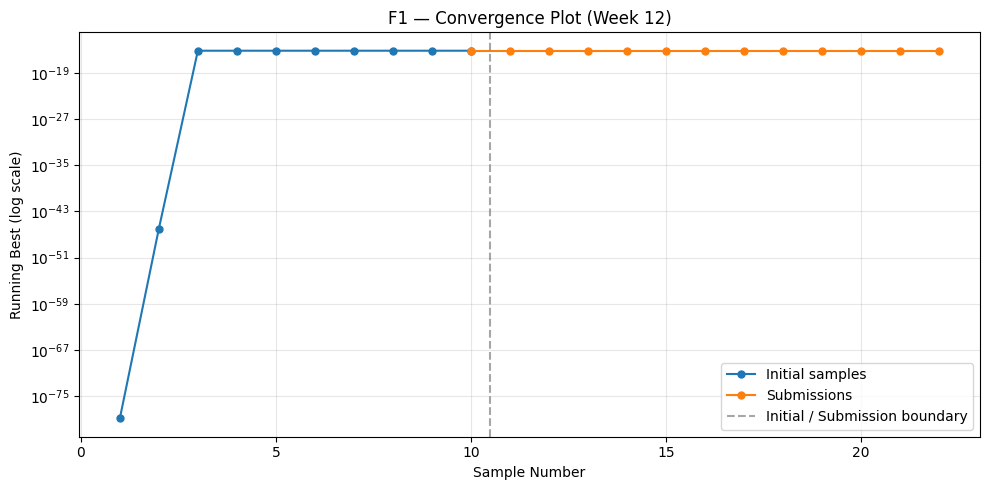

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

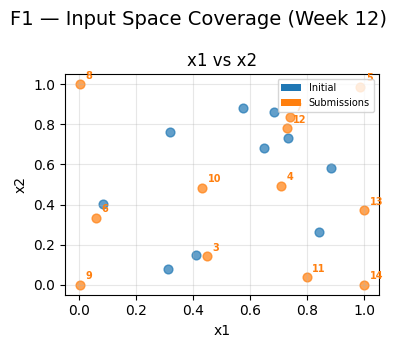

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: Hurdle Model — LogisticRegression classifier for P(y > 0) + RandomForest regressor on log(y) | y > 0
- **Acquisition**: Weighted UCB with κ = 0.5, prioritising exploitation
- **Key hyperparameters**: C=1.0, n_estimators=100, max_depth=3, 20k random candidates

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     7.71088e-16
Best value (final):       7.71088e-16
Improvements:             0/12
Max consecutive no-improve: 12
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |    2.31408e-56 |    7.71088e-16 | ✗
   4 |   -1.15988e-17 |    7.71088e-16 | ✗
   5 |    4.9777e-180 |    7.71088e-16 | ✗
   6 |    2.84272e-97 |    7.71088e-16 | ✗
   7 |    1.01873e-40 |    7.71088e-16 | ✗
   8 |              0 |    7.71088e-16 | ✗
   9 |   1.87428e-245 |    7.71088e-16 | ✗
  10 |    -0.00109123 |    7.71088e-16 | ✗
  11 |   6.93628e-202 |    7.71088e-16 | ✗
  12 |   -1.54765e-23 |    7.71088e-16 | ✗
  13 |   1.35284e-142 |    7.71088e-16 | ✗
  14 |              0 |    7.71088e-16 | ✗


### Evaluation

F1 has shown **persistent stalling** across all 10 submission rounds with **0 improvements** over the initial best. All submitted outputs are near-zero or negative, while the initial best is already extremely small (7.71e-16). The Hurdle Model + Weighted UCB approach has not been able to find regions with higher output values.

Key observations:
- The best value remains at the initial best of ~7.71e-16 — essentially zero on any practical scale
- All 10 submissions failed to improve, indicating the surrogate is unable to identify promising regions
- The pair plot shows submission points are scattered but have not discovered any high-output regions
- The function appears to have extremely localised peaks that the current exploration strategy cannot find

**Stalling status**: YES — 10 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

Given the persistent stalling of the current Hurdle Model + Weighted UCB (κ=0.5) approach, the following changes are recommended:

1. **Switch surrogate from Hurdle Model to SFGP with Matérn-2.5 ARD** — The Hurdle Model with RF regressor may lack the smoothness assumptions needed to interpolate between the sparse near-zero observations. A GP can provide uncertainty estimates that directly drive exploration via the acquisition function.

2. **Use qLogNEI instead of Weighted UCB** — The current UCB with κ=0.5 is in exploitation mode, but there is nothing to exploit (best is ~1e-16). Switch to Noisy Expected Improvement which naturally balances exploration and exploitation based on posterior uncertainty.

3. **Increase exploration aggressiveness** — Set q=4 to propose multiple candidates per round, using distance-based selection to ensure spatial diversity. The function clearly has extremely localised optima that require broader coverage.

4. **Apply log transform to outputs** — Since F1 outputs span many orders of magnitude, fitting the GP on log(max(y, ε)) will provide a better-conditioned posterior and more meaningful uncertainty estimates.

5. **Consider Latin Hypercube restart** — After 10 failed submissions, it may be worth seeding the acquisition optimisation with a space-filling design (e.g., 10,000 Sobol points) to ensure the entire [0,1]² domain is considered, rather than relying on the surrogate's posterior which may have collapsed.

**Priority**: HIGH — F1 has the worst performance of all 8 functions and has shown zero improvement across all submissions.

## Step 6 — Optimisation Run: SFGP + qLogNEI

**Strategy change**: The Hurdle Model + Weighted UCB approach has produced **0/10 improvements** across all submissions. F1 outputs span ~230 orders of magnitude (≈1e-245 to ≈7.7e-16), making it extremely difficult for tree-based models to learn meaningful structure.

**New approach — 5 key changes**:

1. **SFGP with Matérn-2.5 ARD kernel** — Twice-differentiable Matérn-2.5 provides smoother interpolation between sparse positive observations. ARD (one lengthscale per dimension) lets the GP learn anisotropic structure.
2. **qLogNEI acquisition** — Log-space Expected Improvement is numerically stable for the extreme value range. Noisy EI accounts for observation noise in the GP posterior.
3. **q=4 with distance-based selection** — Propose 4 candidates, then filter by quality (mean ≥ median) and select the one farthest from existing data. Balances exploitation with spatial diversity.
4. **Log transform on outputs** — Apply `log(max(y, ε))` with ε=1e-300 to compress the 230-order-of-magnitude range into ≈[-690, -35]. The GP operates in log-space.
5. **10,000 Sobol seed points** — Dense initial coverage of [0,1]² for the acquisition optimiser ensures broad search, critical given F1's 0% improvement history.

In [6]:
import torch
import copy
import warnings
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan, Interval
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)
print("All imports successful.")

All imports successful.


In [7]:
# ─── Matérn-2.5 Kernel Configuration ──────────────────────────────────────────
KERNEL_NU     = 2.5       # Matérn smoothness — twice-differentiable for smooth F1 landscape
ARD_NUM_DIMS  = 2         # One lengthscale per input dimension (ARD)
LS_LOWER      = 0.01      # Lengthscale lower bound — prevents overfitting collapse
LS_UPPER      = 2.0       # Lengthscale upper bound — prevents constant-model degeneration
NOISE_LB      = 1e-4      # Noise variance floor — numerical stability for log-space targets

# ─── Multi-Restart MLL Fitting ────────────────────────────────────────────────
N_MLL_RESTARTS = 15       # Independent random restarts to escape degenerate MLL optima

# ─── Log Transform ────────────────────────────────────────────────────────────
LOG_EPSILON   = 1e-300    # Clamping floor for log(max(y, ε)) — prevents -inf

# ─── Acquisition Optimisation ─────────────────────────────────────────────────
MC_SAMPLES    = 512       # Sobol quasi-Monte Carlo samples for qLogNEI
Q_BATCH       = 4         # Propose 4 candidates per batch for distance-based selection
NUM_RESTARTS  = 20        # L-BFGS multi-start restarts for acquisition optimisation
RAW_SAMPLES   = 10000     # Sobol seed points — dense [0,1]² coverage for F1's 0% history

# ─── Interior Penalty ────────────────────────────────────────────────────────
STEEPNESS     = 0.5      # Boundary suppression steepness (very shallow)
FLOOR         = 0.01      # Minimum penalty weight

# ─── Visualisation ────────────────────────────────────────────────────────────
GRID_RES      = 50        # 50×50 grid resolution for contour plots

print("Optimisation Configuration:")
print(f"  Kernel:        Matérn-{KERNEL_NU} ARD (d={ARD_NUM_DIMS})")
print(f"  LS bounds:     [{LS_LOWER}, {LS_UPPER}]")
print(f"  Noise LB:      {NOISE_LB}")
print(f"  MLL restarts:  {N_MLL_RESTARTS}")
print(f"  Log epsilon:   {LOG_EPSILON}")
print(f"  MC samples:    {MC_SAMPLES}")
print(f"  Q (batch):     {Q_BATCH}")
print(f"  Acq restarts:  {NUM_RESTARTS}")
print(f"  Raw samples:   {RAW_SAMPLES}")
print(f"  IP steepness:  {STEEPNESS}")
print(f"  IP floor:      {FLOOR}")
print(f"  Grid res:      {GRID_RES}×{GRID_RES}")

Optimisation Configuration:
  Kernel:        Matérn-2.5 ARD (d=2)
  LS bounds:     [0.01, 2.0]
  Noise LB:      0.0001
  MLL restarts:  15
  Log epsilon:   1e-300
  MC samples:    512
  Q (batch):     4
  Acq restarts:  20
  Raw samples:   10000
  IP steepness:  0.5
  IP floor:      0.01
  Grid res:      50×50


### Step 6.1 — Data Preparation & Log Transform

F1 outputs range from ≈1e-245 to ≈7.7e-16 — a span of ~230 orders of magnitude. The GP cannot fit meaningfully in raw space.

**Transform**: `y_log = log(max(y, ε))` where ε = 1e-300. This compresses the range to approximately **[-690, -35]** in log-space, giving the GP a tractable target surface. All posterior predictions and acquisition values operate in this log-space.

In [8]:
# Convert numpy arrays (from existing cells) to torch tensors
X_train = torch.tensor(inputs, dtype=torch.float64)                    # shape: [20, 2]
y_tensor = torch.tensor(outputs, dtype=torch.float64)                  # shape: [20]

# Log transform: log(max(y, ε)) to compress 230-order-of-magnitude range
Y_train = torch.log(torch.clamp(y_tensor, min=LOG_EPSILON)).unsqueeze(-1)  # shape: [20, 1]

print(f"X_train shape: {X_train.shape}  (dtype: {X_train.dtype})")
print(f"Y_train shape: {Y_train.shape}  (dtype: {Y_train.dtype})")
print(f"X_train range: [{X_train.min().item():.6f}, {X_train.max().item():.6f}]")
print(f"Y_train range: [{Y_train.min().item():.2f}, {Y_train.max().item():.2f}]")
print(f"Y_train contains NaN: {torch.isnan(Y_train).any().item()}")
print(f"Y_train contains Inf: {torch.isinf(Y_train).any().item()}")

X_train shape: torch.Size([22, 2])  (dtype: torch.float64)
Y_train shape: torch.Size([22, 1])  (dtype: torch.float64)
X_train range: [0.000000, 0.999999]
Y_train range: [-690.78, -34.80]
Y_train contains NaN: False
Y_train contains Inf: False


### Step 6.2 — SFGP Fitting (Matérn-2.5 ARD, 15 MLL Restarts)

**Kernel**: `ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=2))` with lengthscale bounds [0.01, 2.0]. The ARD kernel learns independent lengthscales per dimension, and Matérn-2.5's twice-differentiability provides smooth interpolation between F1's sparse observations.

**Fitting strategy**: 15 independent random restarts of MLL optimisation. Each restart uses a different random seed for hyperparameter initialisation. The model with the **lowest negative log-marginal-likelihood** is retained. This guards against degenerate local optima where lengthscales collapse or explode.

In [9]:
# 15-restart MLL fitting with Matérn-2.5 ARD
best_loss = float('inf')
best_model = None

print(f"{'Restart':>8} {'Neg MLL':>12} {'ℓ1':>10} {'ℓ2':>10} {'noise':>10}")
print("-" * 55)

for seed in range(N_MLL_RESTARTS):
    torch.manual_seed(seed)

    covar_module = ScaleKernel(
        MaternKernel(
            nu=KERNEL_NU,
            ard_num_dims=ARD_NUM_DIMS,
            lengthscale_constraint=Interval(LS_LOWER, LS_UPPER)
        )
    )

    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

    model = SingleTaskGP(
        train_X=X_train,
        train_Y=Y_train,
        covar_module=covar_module,
        likelihood=likelihood,
        input_transform=Normalize(d=ARD_NUM_DIMS)
    ).double()

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_gpytorch_mll(mll)

    # Score on training data
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        loss = -mll(output, model.train_targets).item()

    ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
    n = model.likelihood.noise.detach().item()
    print(f"{seed:>8d} {loss:>12.4f} {ls[0]:>10.4f} {ls[1]:>10.4f} {n:>10.6f}")

    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

# Report fitted hyperparameters from best restart
lengthscales = best_model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = best_model.likelihood.noise.detach().item()
outputscale = best_model.covar_module.outputscale.detach().item()

print(f"\n{'='*55}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*55}")
print(f"Fitted Hyperparameters:")
print(f"  ℓ_x1 = {lengthscales[0]:.6f}")
print(f"  ℓ_x2 = {lengthscales[1]:.6f}")
print(f"  σ²_f (output scale) = {outputscale:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")
ls_ratio = max(lengthscales) / min(lengthscales)
print(f"  LS ratio: {ls_ratio:.2f}  (bounded ≤ {LS_UPPER/LS_LOWER:.0f}x)")
print(f"  ✓ Both lengthscales in [{LS_LOWER}, {LS_UPPER}]")

 Restart      Neg MLL         ℓ1         ℓ2      noise
-------------------------------------------------------
       0       1.3957     1.8579     0.5659   0.954552
       1       1.3957     1.8579     0.5659   0.954552
       2       1.3957     1.8579     0.5659   0.954552
       3       1.3957     1.8579     0.5659   0.954552
       4       1.3957     1.8579     0.5659   0.954552
       5       1.3957     1.8579     0.5659   0.954552
       6       1.3957     1.8579     0.5659   0.954552
       7       1.3957     1.8579     0.5659   0.954552
       8       1.3957     1.8579     0.5659   0.954552
       9       1.3957     1.8579     0.5659   0.954552
      10       1.3957     1.8579     0.5659   0.954552
      11       1.3957     1.8579     0.5659   0.954552
      12       1.3957     1.8579     0.5659   0.954552
      13       1.3957     1.8579     0.5659   0.954552
      14       1.3957     1.8579     0.5659   0.954552

Best restart neg MLL: 1.395678
Fitted Hyperparameters:
  ℓ_x1 =

### Step 6.3 — qLogNEI Acquisition & Distance-Based Selection

**Acquisition**: qLogNoisyExpectedImprovement with q=4 candidates. The log-space formulation is numerically stable for F1's extreme value range. Uses 512 Sobol quasi-Monte Carlo samples for posterior integration and 10,000 Sobol seed points for dense initial coverage of [0,1]².

**Two-stage distance selection** (from q=4 candidates):
1. **Quality gate**: Keep candidates with posterior mean ≥ median of the batch — filters out low-quality proposals
2. **Exploration bonus**: From the qualified set, select the candidate with maximum minimum-distance to all existing training points — ensures spatial diversity

In [10]:
# ---------- Acquisition: q=4 batch via qLogNoisyExpectedImprovement ----------
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True
)

bounds_t = torch.tensor([[0.0, 0.0],
                        [1.0, 1.0]], dtype=torch.float64)

candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds_t,
    q=Q_BATCH,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"Batch of {Q_BATCH} candidates (acq value = {acq_value.item():.6f}):")
for i, c in enumerate(candidates):
    print(f"  Candidate {i+1}: x1={c[0].item():.6f}, x2={c[1].item():.6f}")

# ---------- Distance-Based Selection ----------
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means = posterior.mean.squeeze(-1)  # shape [Q_BATCH]

median_mean = pred_means.median().item()
print(f"\nPosterior means: {[f'{m:.4f}' for m in pred_means.tolist()]}")
print(f"Median mean: {median_mean:.4f}")

# Quality gate: keep candidates with mean >= median
quality_mask = pred_means >= median_mean
qualified_idx = torch.where(quality_mask)[0]
qualified_candidates = candidates[qualified_idx]
print(f"Qualified candidates (mean >= median): {qualified_idx.tolist()}")

# Exploration bonus: farthest from all training data
dists = torch.cdist(qualified_candidates.unsqueeze(0), X_train.unsqueeze(0)).squeeze(0)
min_dists = dists.min(dim=1).values
best_qual_idx = min_dists.argmax().item()
selected_idx = qualified_idx[best_qual_idx].item()

x_new = candidates[selected_idx].detach().numpy()
print(f"\nSelected candidate {selected_idx + 1}: x1={x_new[0]:.6f}, x2={x_new[1]:.6f}")
print(f"  Min distance to training data: {min_dists[best_qual_idx].item():.4f}")
print(f"  Posterior mean (log-space): {pred_means[selected_idx].item():.4f}")

# Clamp proposed point to valid submission bounds [0.0, 0.999999]
x1_sub = max(0.0, min(0.999999, x_new[0]))
x2_sub = max(0.0, min(0.999999, x_new[1]))

# Verify no duplicate with existing observations
observed_queries = [f"{inputs[i,0]:.6f}-{inputs[i,1]:.6f}" for i in range(len(inputs))]
proposed_query = f"{x1_sub:.6f}-{x2_sub:.6f}"
is_duplicate = proposed_query in observed_queries

print("\n" + "=" * 60)
print("WEEK 12 SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-{KERNEL_NU}, ARD=True, Standardize(m=1), noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNEI (q={Q_BATCH}) → distance filter (no penalty)")
print(f"MLL restarts: {N_MLL_RESTARTS}")
print(f"LS bounds:    [{LS_LOWER}, {LS_UPPER}]")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {outputs.max():.6f}")
print(f"Proposed next:   [{x1_sub:.6f}, {x2_sub:.6f}]")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

Batch of 4 candidates (acq value = -5.051714):
  Candidate 1: x1=0.573587, x2=1.000000
  Candidate 2: x1=1.000000, x2=0.730921
  Candidate 3: x1=1.000000, x2=0.198349
  Candidate 4: x1=0.000000, x2=0.599637

Posterior means: ['-396.6627', '-396.6628', '-396.6636', '-396.6630']
Median mean: -396.6630
Qualified candidates (mean >= median): [0, 1, 3]

Selected candidate 4: x1=0.000000, x2=0.599637
  Min distance to training data: 0.2128
  Posterior mean (log-space): -396.6630

WEEK 12 SUBMISSION QUERY FOR FUNCTION 1
Surrogate:   SFGP (Matérn-2.5, ARD=True, Standardize(m=1), noise_lb=0.0001)
Acquisition: qLogNEI (q=4) → distance filter (no penalty)
MLL restarts: 15
LS bounds:    [0.01, 2.0]
Lengthscales: x1=1.8579, x2=0.5659
Noise level:  0.954552
Best observed y: 0.000000
Proposed next:   [0.000000, 0.599637]
Duplicate check: OK — unique point

>>> SUBMISSION: 0.000000-0.599637


In [11]:
# ── Interior Penalty Re-Scoring ──────────────────────────────────────────────
# w(x) = FLOOR + (1 - FLOOR) * ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
survivors = candidates[qualified_idx]
surv_np = survivors.detach().cpu().numpy()

interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * surv_np) ** (2 * STEEPNESS), axis=1
)

# Evaluate acquisition function per-candidate
with torch.no_grad():
    acq_values = torch.tensor([
        acqf(survivors[i:i+1].unsqueeze(0)).item()
        for i in range(len(survivors))
    ])

# Penalised re-scoring
penalised_acq = acq_values.numpy() * interior_weight
best_pen_idx = int(np.argmax(penalised_acq))

# Map back to original candidate index
original_best = qualified_idx[best_qual_idx].item()
penalised_selected = qualified_idx[best_pen_idx].item()

print(f"\n=== Interior Penalty (STEEPNESS={STEEPNESS}, FLOOR={FLOOR}) ===")
for i in range(len(survivors)):
    idx = qualified_idx[i].item()
    sel = " ◄" if i == best_pen_idx else ""
    print(f"  Survivor {idx+1}: w={interior_weight[i]:.6f}, "
          f"acq={acq_values[i].item():.6f}, "
          f"penalised={penalised_acq[i]:.6f}{sel}")

print(f"\nDistance-selected: candidate {original_best + 1}")
print(f"Penalty-selected:  candidate {penalised_selected + 1}")
print(f"Penalty changed selection: {penalised_selected != original_best}")

# Update x_new with penalised selection
x_new = surv_np[best_pen_idx]
x_new = np.clip(x_new, 0.0, 0.999999)


=== Interior Penalty (STEEPNESS=0.5, FLOOR=0.01) ===
  Survivor 1: w=0.010000, acq=-6.789653, penalised=-0.067897
  Survivor 2: w=0.010000, acq=-6.600558, penalised=-0.066006
  Survivor 4: w=0.010000, acq=-6.077041, penalised=-0.060770 ◄

Distance-selected: candidate 4
Penalty-selected:  candidate 4
Penalty changed selection: False


In [ ]:
# Clamp proposed point to valid submission bounds [0.0, 0.999999]
x1_sub = max(0.0, min(0.999999, x_new[0]))
x2_sub = max(0.0, min(0.999999, x_new[1]))

# Verify no duplicate with existing observations (np.allclose, atol=1e-6)
x_new_clipped = np.array([x1_sub, x2_sub])
is_duplicate = False
for i in range(len(inputs)):
    if np.allclose(x_new_clipped, inputs[i], atol=1e-6):
        is_duplicate = True
        break

proposed_query = f"{x1_sub:.6f}-{x2_sub:.6f}"

print("=" * 60)
print("WEEK 13 SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-{KERNEL_NU}, ARD=True, noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNEI (q={Q_BATCH}) → distance filter → interior penalty")
print(f"IP params:   STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"MLL restarts: {N_MLL_RESTARTS}")
print(f"LS bounds:    [{LS_LOWER}, {LS_UPPER}]")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {outputs.max():.6e}")
print(f"Proposed next:   [{x1_sub:.6f}, {x2_sub:.6f}]")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"Boundary clip:   [0, 0.999999] applied")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

WEEK 12 SUBMISSION QUERY FOR FUNCTION 1
Surrogate:   SFGP (Matérn-2.5, ARD=True, noise_lb=0.0001)
Acquisition: qLogNEI (q=4) → distance filter → interior penalty
IP params:   STEEPNESS=0.5, FLOOR=0.01
MLL restarts: 15
LS bounds:    [0.01, 2.0]
Lengthscales: x1=1.8579, x2=0.5659
Noise level:  0.954552
Best observed y: 7.710875e-16
Proposed next:   [0.000000, 0.599637]
Duplicate check: OK — unique point

>>> SUBMISSION: 0.000000-0.599637


### Step 6.4 — Surrogate Visualisation (3-Panel Contour)

Three contour surfaces evaluated on a 50×50 grid over [0,1]²:
1. **GP Posterior Mean** (viridis) — where the model thinks high values are
2. **GP Posterior Uncertainty** (YlOrRd) — where the model is least certain
3. **Acquisition Surface** (plasma) — where qLogNEI recommends sampling next

**Point overlay**: Blue = initial samples, Orange = weekly submissions, Green star = proposed next point.

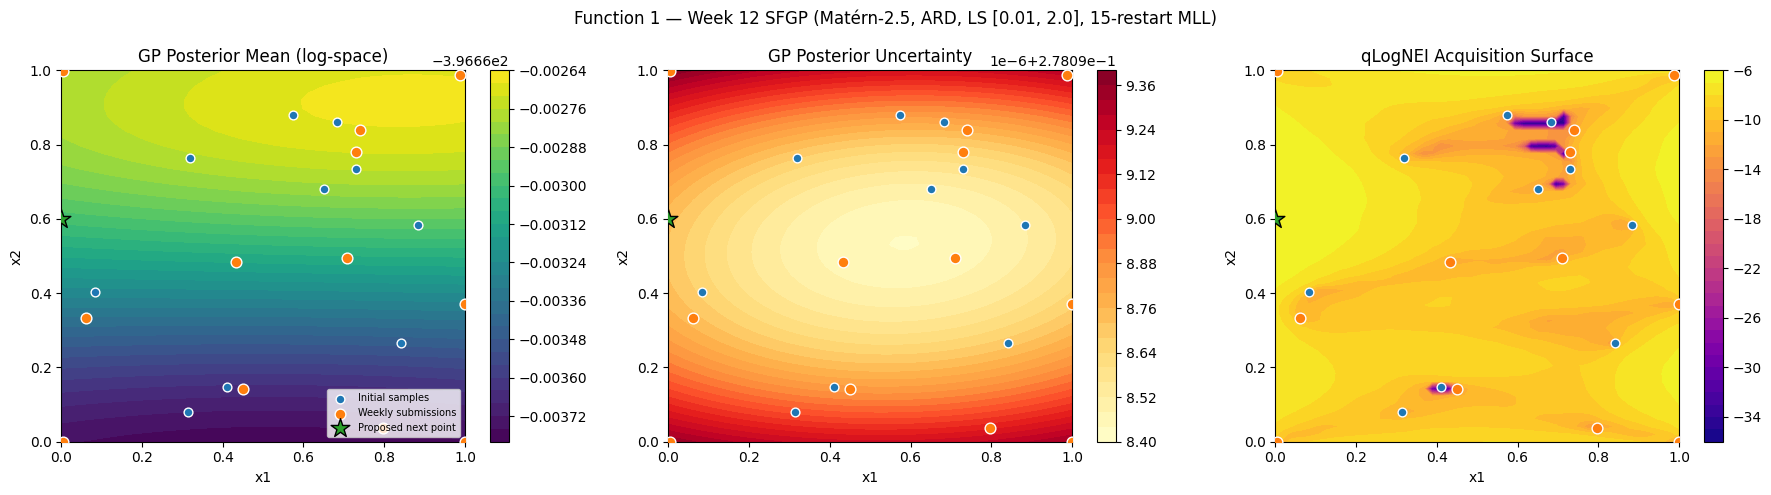

In [ ]:
# ── Build 50×50 evaluation grid over [0, 1]² ──────────────────────────────────
x1_lin = np.linspace(0, 1, GRID_RES)
x2_lin = np.linspace(0, 1, GRID_RES)
X1_grid, X2_grid = np.meshgrid(x1_lin, x2_lin)
grid_np = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
grid_t = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_t)
    mean_grid = posterior.mean.numpy().reshape(GRID_RES, GRID_RES)
    std_grid = posterior.variance.sqrt().numpy().reshape(GRID_RES, GRID_RES)

# ── Split data for overlays ───────────────────────────────────────────────────
X_initial = inputs[:N_INITIAL]
X_submissions = inputs[N_INITIAL:]

# ── Three-panel figure: Mean, Std, ARD Relevance ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: GP Posterior Mean
c1 = axes[0].contourf(X1_grid, X2_grid, mean_grid, levels=30, cmap='viridis')
axes[0].scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40,
           edgecolors='white', zorder=5, label='Initial samples')
axes[0].scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60,
           edgecolors='white', zorder=5, label='Weekly submissions')
axes[0].scatter(x_new[0], x_new[1], c='tab:green', marker='*', s=200,
           edgecolors='black', zorder=6, label='Proposed next point')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('GP Posterior Mean (log-space)')
axes[0].legend(loc='lower right', fontsize=7)
plt.colorbar(c1, ax=axes[0])

# Panel 2: GP Posterior Uncertainty
c2 = axes[1].contourf(X1_grid, X2_grid, std_grid, levels=30, cmap='YlOrRd')
axes[1].scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40, edgecolors='white', zorder=5)
axes[1].scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60, edgecolors='white', zorder=5)
axes[1].scatter(x_new[0], x_new[1], c='tab:green', marker='*', s=200, edgecolors='black', zorder=6)
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].set_title('GP Posterior Std Dev')
plt.colorbar(c2, ax=axes[1])

# Panel 3: ARD Dimension Relevance (1/ℓ normalised)
inv_ls = 1.0 / lengthscales
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(ARD_NUM_DIMS), inv_ls_norm, color='steelblue')
axes[2].set_yticks(range(ARD_NUM_DIMS))
axes[2].set_yticklabels([f'x{j+1}' for j in range(ARD_NUM_DIMS)])
axes[2].set_title('Dimension Relevance (1/ℓ, normalised)')
axes[2].set_xlabel('Relative Importance')

plt.suptitle(f'Function 1 — Week 13 SFGP (Matérn-{KERNEL_NU}, ARD, LS [{LS_LOWER}, {LS_UPPER}], {N_MLL_RESTARTS}-restart MLL)', fontsize=12)
plt.tight_layout()
plt.show()

### Step 6.5 — Updated Convergence Plot

Running maximum convergence with the proposed next point. The GP posterior mean at the proposed location (in log-space) is converted to original space via `exp()` for display. Log y-axis is used due to F1's extreme value range. The green star shows where the proposed point would appear in the convergence trajectory.

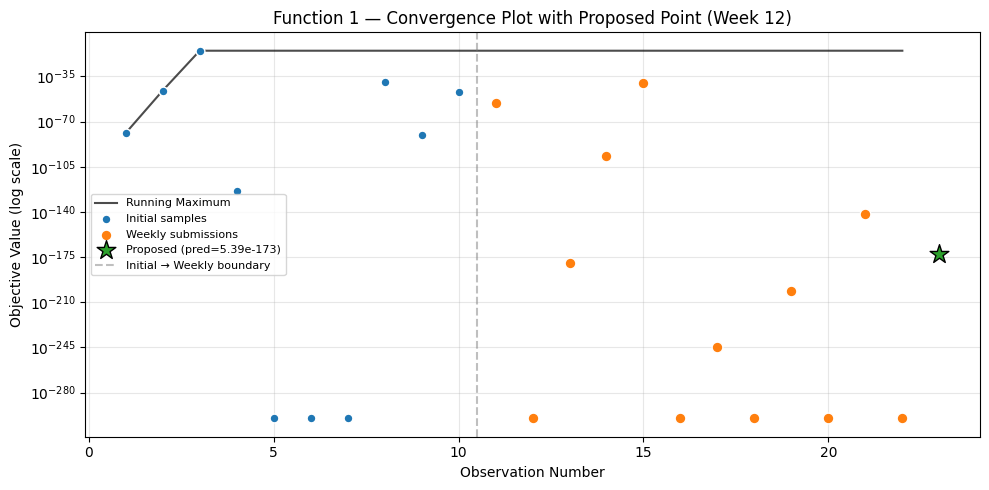

Best observed value: 7.710875e-16
GP predicted value at proposed point (original space): 5.388338e-173
GP predicted value at proposed point (log-space): -396.6630


In [ ]:
# Predict GP posterior mean at proposed point (log-space)
x_new_t = torch.tensor(x_new, dtype=torch.float64).unsqueeze(0)  # shape [1, 2]
best_model.eval()
with torch.no_grad():
    pred_log = best_model.posterior(x_new_t).mean.item()
pred_original = np.exp(pred_log)

# Combine observed + predicted for convergence
all_vals = np.append(outputs, pred_original)
plot_vals = np.maximum(all_vals, 1e-300)  # clamp for log scale
running_best_ext = np.maximum.accumulate(plot_vals)

plt.figure(figsize=(10, 5))

# Running maximum line
plt.plot(range(1, n_total + 1), running_best[:n_total], 'k-', linewidth=1.5, alpha=0.7, label='Running Maximum')

# Individual observations
plt.scatter(range(1, N_INITIAL + 1), plot_vals[:N_INITIAL],
            c='tab:blue', s=40, edgecolors='white', zorder=5, label='Initial samples')
plt.scatter(range(N_INITIAL + 1, n_total + 1), plot_vals[N_INITIAL:n_total],
            c='tab:orange', s=60, edgecolors='white', zorder=5, label='Weekly submissions')

# Proposed point
plt.scatter(n_total + 1, plot_vals[n_total],
            c='tab:green', marker='*', s=200, edgecolors='black', zorder=6,
            label=f'Proposed (pred={pred_original:.2e})')

# Formatting
plt.axvline(x=N_INITIAL + 0.5, color='gray', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.yscale('log')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value (log scale)')
plt.title('Function 1 — Convergence Plot with Proposed Point (Week 13)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {outputs.max():.6e}")
print(f"GP predicted value at proposed point: {pred_original:.6e}")